In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn

from collections import Counter
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
train_df = pd.read_csv("../data/train_balanced.csv")
validation_df = pd.read_csv("../data/validation.csv")
test_df = pd.read_csv("../data/test.csv")

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Training shape: (1227, 5)
Validation shape: (760, 5)
Test shape: (760, 5)


,label,message,labeled,clean_message,lemmatized_text
0,spam,"URGENT!: Your Mobile No. was awarded a å£2,000...",0,urgent! your mobile no was awarded a å moneyto...,urgent ! mobile no award å moneytoken bonus ca...
1,ham,Not course. Only maths one day one chapter wit...,1,not course only maths one day one chapter with...,not course maths one day one chapter one month...
2,spam,"Hi there, 2nights ur lucky night! Uve been inv...",0,hi there 2nights ur lucky night! uve been invi...,hi ur lucky night ! uve invite numbertoken xch...
3,ham,Hi mom we might be back later than &lt;#&gt;,1,hi mom we might be back later than,hi mom might back later
4,ham,Congrats. That's great. I wanted to tell you n...,1,congrats that is great i wanted to tell you no...,congrats great want tell not tell score co mig...


In [3]:
# Select the text and target columns
TEXT_COLUMN = "lemmatized_text"
LABEL_COLUMN = "label"

for name, df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Missing text:", df[TEXT_COLUMN].isna().sum())
    print("Labels:")
    print(df[LABEL_COLUMN].value_counts())


Training
Shape: (1227, 5)
Missing text: 0
Labels:
label
ham     818
spam    409
Name: count, dtype: int64

Validation
Shape: (760, 5)
Missing text: 0
Labels:
label
ham     673
spam     87
Name: count, dtype: int64

Test
Shape: (760, 5)
Missing text: 0
Labels:
label
ham     672
spam     88
Name: count, dtype: int64


In [4]:
# Build the vocabulary from training data only to avoid leakage.
# The text is already cleaned and whitespace-tokenized by preprocessing.
PAD_ID = 0
OOV_ID = 1

word_counts = Counter(
    token
    for text in train_df[TEXT_COLUMN].astype(str)
    for token in text.lower().split()
)

word_index = {"<OOV>": OOV_ID}
for word, _ in word_counts.most_common():
    if word not in word_index:
        word_index[word] = len(word_index) + 1

vocab_size = len(word_index) + 1  # include padding row 0

print("Vocabulary size:", vocab_size)
print("First 40 tokens:")
print(list(word_index.items())[:40])

Vocabulary size: 2886
First 40 tokens:
[('<OOV>', 1), ('numbertoken', 2), ('!', 3), ('?', 4), ('u', 5), ('phonetoken', 6), ('call', 7), ('moneytoken', 8), ('not', 9), ('get', 10), ('å', 11), ('free', 12), ('ur', 13), ('txt', 14), ('go', 15), ('text', 16), ('no', 17), ('reply', 18), ('stop', 19), ('send', 20), ('mobile', 21), ('c', 22), ('come', 23), ('time', 24), ('want', 25), ('claim', 26), ('know', 27), ('new', 28), ('week', 29), ('urltoken', 30), ('day', 31), ('tone', 32), ('ok', 33), ('msg', 34), ('please', 35), ('good', 36), ('min', 37), ('tell', 38), ('make', 39), ('say', 40)]


In [5]:
# Convert text into sequences of token IDs
def texts_to_sequences(texts):
    return [
        [word_index.get(token, OOV_ID) for token in str(text).lower().split()]
        for text in texts
    ]

train_sequences = texts_to_sequences(train_df[TEXT_COLUMN])
validation_sequences = texts_to_sequences(validation_df[TEXT_COLUMN])
test_sequences = texts_to_sequences(test_df[TEXT_COLUMN])

In [6]:
print("\nOriginal text:")
print(train_df[TEXT_COLUMN].iloc[0])

print("\nNumerical sequence:")
print(train_sequences[0])


Original text:
urgent ! mobile no award å moneytoken bonus caller prize numbertoken numbertoken numbertoken ! attempt contact ! call phonetoken

Numerical sequence:
[66, 3, 21, 17, 77, 11, 8, 235, 323, 44, 2, 2, 2, 3, 165, 61, 3, 7, 6]


In [7]:
train_lengths = np.array([len(sequence) for sequence in train_sequences])

print("Shortest message:", train_lengths.min())
print("Average length:", train_lengths.mean())
print("Median length:", np.median(train_lengths))
print("95th percentile:", np.percentile(train_lengths, 95))
print("Longest message:", train_lengths.max())


Shortest message: 1
Average length: 11.599837000814995
Median length: 9.0
95th percentile: 24.0
Longest message: 64


**take a fixed length of 30 because it covers more than 95% of the data and pad if there is less**

In [8]:
MAX_LENGTH = 30

def pad_sequences(sequences, max_length, padding_value=PAD_ID):
    padded = np.full(
        (len(sequences), max_length),
        padding_value,
        dtype=np.int64
    )
    for row, sequence in enumerate(sequences):
        truncated = sequence[:max_length]
        padded[row, :len(truncated)] = truncated
    return padded

X_train = pad_sequences(train_sequences, MAX_LENGTH)
X_validation = pad_sequences(validation_sequences, MAX_LENGTH)
X_test = pad_sequences(test_sequences, MAX_LENGTH)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nOriginal sequence:")
print(train_sequences[0])

print("\nPadded sequence:")
print(X_train[0])

Training shape: (1227, 30)
Validation shape: (760, 30)
Test shape: (760, 30)

Original sequence:
[66, 3, 21, 17, 77, 11, 8, 235, 323, 44, 2, 2, 2, 3, 165, 61, 3, 7, 6]

Padded sequence:
[ 66   3  21  17  77  11   8 235 323  44   2   2   2   3 165  61   3   7
   6   0   0   0   0   0   0   0   0   0   0   0]


Convert labels to numeric arrays with spam as the positive class (`spam = 1`, `ham = 0`). These arrays will be converted to PyTorch tensors before training.

In [9]:
y_train = (train_df[LABEL_COLUMN] == "spam").astype("float32").to_numpy()
y_validation = (validation_df[LABEL_COLUMN] == "spam").astype("float32").to_numpy()
y_test = (test_df[LABEL_COLUMN] == "spam").astype("float32").to_numpy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nLabel mapping: spam = 1, ham = 0")

X_train shape: (1227, 30)
y_train shape: (1227,)

Label mapping: spam = 1, ham = 0


## GloVe Embedding Preparation

In [10]:
GLOVE_PATH = "../data/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt"
EMBEDDING_DIM = 100

required_words = set(word_index.keys())
embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8", errors="ignore") as glove_file:
    for line in glove_file:
        values = line.rstrip().split()

        # one word plus 100 vector values
        if len(values) != EMBEDDING_DIM + 1:
            continue

        word = values[0]

        if word in required_words:
            embeddings_index[word] = np.asarray(
                values[1:],
                dtype="float32"
            )

print("Training vocabulary:", len(required_words))
print("Words found in GloVe:", len(embeddings_index))

coverage = len(embeddings_index) / len(required_words) * 100
print(f"Vocabulary coverage: {coverage:.2f}%")

Training vocabulary: 2885
Words found in GloVe: 2572
Vocabulary coverage: 89.15%


In [11]:
rng = np.random.default_rng(SEED)

# Random initial vectors for vocabulary words
embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.05,
    size=(vocab_size, EMBEDDING_DIM)
).astype("float32")

# ID 0 represents padding and must remain zeros
embedding_matrix[0] = np.zeros(EMBEDDING_DIM, dtype="float32")

# Insert pretrained GloVe vectors
for word, token_id in word_index.items():
    glove_vector = embeddings_index.get(word)

    if glove_vector is not None:
        embedding_matrix[token_id] = glove_vector

print("Embedding matrix shape:", embedding_matrix.shape)
print("Expected shape:", (vocab_size, EMBEDDING_DIM))

Embedding matrix shape: (2886, 100)
Expected shape: (2886, 100)


## PyTorch Data Preparation

These tensors, message lengths, batches, and device settings are shared by the RNN, GRU, and LSTM.

In [12]:
# Convert inputs, labels, and GloVe vectors to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
X_validation_tensor = torch.tensor(X_validation, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

print("X train:", X_train_tensor.shape)
print("y train:", y_train_tensor.shape)
print("Embeddings:", embedding_tensor.shape)

X train: torch.Size([1227, 30])
y train: torch.Size([1227])
Embeddings: torch.Size([2886, 100])


### Save each message's real length

This lets each recurrent model ignore padding when it selects the final real word.

In [13]:
def get_lengths(sequences):
    lengths = [min(len(sequence), MAX_LENGTH) for sequence in sequences]
    return torch.tensor(lengths, dtype=torch.long)

train_lengths_tensor = get_lengths(train_sequences)
validation_lengths_tensor = get_lengths(validation_sequences)
test_lengths_tensor = get_lengths(test_sequences)

### Group the data into batches

In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor, train_lengths_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

validation_loader = DataLoader(
    TensorDataset(X_validation_tensor, y_validation_tensor, validation_lengths_tensor),
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor, test_lengths_tensor),
    batch_size=BATCH_SIZE
)

### Select the processor

In [15]:
device = torch.device("mps")

print("Using device:", device)

Using device: mps


## Shared Training and Evaluation Functions

The same functions train and evaluate every model below.


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

def calculate_loss(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for token_ids, labels, lengths in data_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            logits = model(token_ids, lengths)
            total_loss += criterion(logits, labels).item()

    return total_loss / len(data_loader)


def train_model(
    model, optimizer, criterion, model_name, epochs=20,
    training_loader=train_loader
):
    training_loader.generator.manual_seed(SEED)
    train_losses = []
    validation_losses = []
    best_validation_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for token_ids, labels, lengths in training_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(training_loader)
        validation_loss = calculate_loss(model, validation_loader, criterion)
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )
        # Stop training when validation loss fails to improve twice.
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch + 1
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == 2:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)
    print(f"Restored weights from epoch {best_epoch}")

    plt.plot(train_losses, label="Training loss")
    plt.plot(validation_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curves")
    plt.legend()
    plt.show()

    return {
        "train": train_losses,
        "validation": validation_losses,
        "best_epoch": best_epoch
    }


def evaluate_model(model, model_name):
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for token_ids, labels, lengths in test_loader:
            token_ids = token_ids.to(device)

            logits = model(token_ids, lengths)
            predictions = (torch.sigmoid(logits) >= 0.5).int()

            true_labels.extend(labels.int().numpy())
            predicted_labels.extend(predictions.cpu().numpy())

    results = {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "precision": precision_score(true_labels, predicted_labels),
        "recall": recall_score(true_labels, predicted_labels),
        "f1": f1_score(true_labels, predicted_labels),
    }

    print(model_name, results)
    print(classification_report(
        true_labels, predicted_labels,
        target_names=["ham", "spam"], zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        true_labels, predicted_labels,
        display_labels=["Ham", "Spam"],
        cmap="Blues", values_format="d"
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return results


## 1. GloVe with Simple RNN

### Define the Simple RNN

In [17]:
class GloveRNN(nn.Module):
    def __init__(self, pretrained_weights, embedding_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            pretrained_weights, freeze=True, padding_idx=PAD_ID
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        hidden = hidden[-1]

        return self.output(hidden).squeeze(1)

### Create the model, loss function, and optimizer

In [18]:
torch.manual_seed(SEED)
train_loader.generator.manual_seed(SEED)

rnn_model = GloveRNN(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32
).to(device)

rnn_criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

print(rnn_model)

GloveRNN(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (rnn): RNN(100, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


### Train the Simple RNN

RNN Baseline | Epoch 1/20 | Train Loss: 0.5862 | Validation Loss: 0.3831
RNN Baseline | Epoch 2/20 | Train Loss: 0.4726 | Validation Loss: 0.3131
RNN Baseline | Epoch 3/20 | Train Loss: 0.2859 | Validation Loss: 0.2023
RNN Baseline | Epoch 4/20 | Train Loss: 0.1925 | Validation Loss: 0.1733
RNN Baseline | Epoch 5/20 | Train Loss: 0.1520 | Validation Loss: 0.1587
RNN Baseline | Epoch 6/20 | Train Loss: 0.1349 | Validation Loss: 0.2095
RNN Baseline | Epoch 7/20 | Train Loss: 0.1193 | Validation Loss: 0.3009
Early stopping at epoch 7
Restored weights from epoch 5


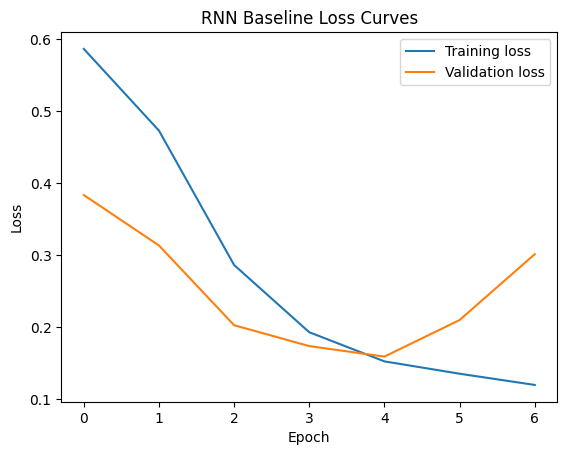

In [19]:
rnn_history = train_model(
    rnn_model, rnn_optimizer, rnn_criterion, "RNN Baseline"
)


### Evaluate the Simple RNN

RNN Baseline {'accuracy': 0.9315789473684211, 'precision': 0.6636363636363637, 'recall': 0.8295454545454546, 'f1': 0.7373737373737373}
              precision    recall  f1-score   support

         ham       0.98      0.94      0.96       672
        spam       0.66      0.83      0.74        88

    accuracy                           0.93       760
   macro avg       0.82      0.89      0.85       760
weighted avg       0.94      0.93      0.93       760



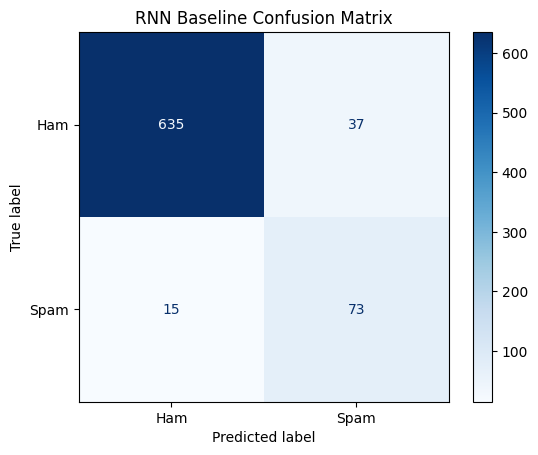

In [20]:
rnn_results = evaluate_model(rnn_model, "RNN Baseline")


## 2. GloVe with GRU

A GRU uses gates to control what information it remembers and forgets.

In [21]:
class GloveGRU(nn.Module):
    def __init__(
        self, pretrained_weights, embedding_dim, hidden_size,
        num_layers, dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            pretrained_weights, freeze=True, padding_idx=PAD_ID
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        hidden = hidden[-1]

        return self.output(hidden).squeeze(1)

### Create the GRU model, loss function, and optimizer

In [22]:
torch.manual_seed(SEED)
train_loader.generator.manual_seed(SEED)

gru_model = GloveGRU(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32,
    num_layers=1,
    dropout=0.0
).to(device)
gru_criterion = nn.BCEWithLogitsLoss()
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

print(gru_model)

GloveGRU(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (gru): GRU(100, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


### Train the GRU

Single-Layer GRU | Epoch 1/20 | Train Loss: 0.5983 | Validation Loss: 0.3924
Single-Layer GRU | Epoch 2/20 | Train Loss: 0.4445 | Validation Loss: 0.2998
Single-Layer GRU | Epoch 3/20 | Train Loss: 0.2460 | Validation Loss: 0.2092
Single-Layer GRU | Epoch 4/20 | Train Loss: 0.1680 | Validation Loss: 0.1665
Single-Layer GRU | Epoch 5/20 | Train Loss: 0.1323 | Validation Loss: 0.1377
Single-Layer GRU | Epoch 6/20 | Train Loss: 0.1128 | Validation Loss: 0.1508
Single-Layer GRU | Epoch 7/20 | Train Loss: 0.0940 | Validation Loss: 0.1685
Early stopping at epoch 7
Restored weights from epoch 5


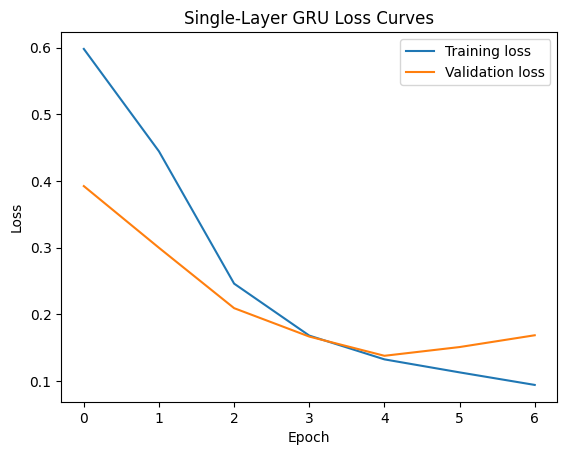

In [23]:
gru_history = train_model(
    gru_model, gru_optimizer, gru_criterion, "Single-Layer GRU"
)


### Evaluate the GRU

Single-Layer GRU {'accuracy': 0.9552631578947368, 'precision': 0.7454545454545455, 'recall': 0.9318181818181818, 'f1': 0.8282828282828283}
              precision    recall  f1-score   support

         ham       0.99      0.96      0.97       672
        spam       0.75      0.93      0.83        88

    accuracy                           0.96       760
   macro avg       0.87      0.95      0.90       760
weighted avg       0.96      0.96      0.96       760



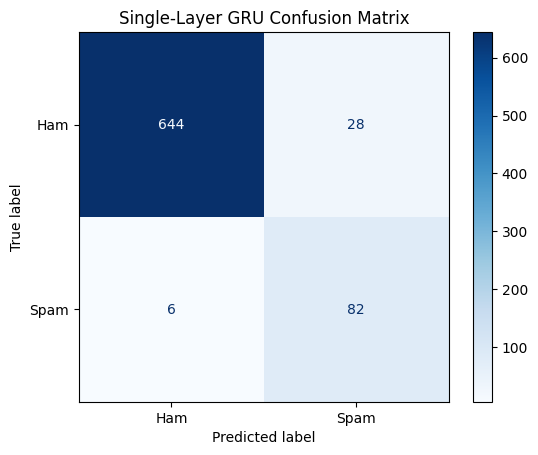

In [24]:
gru_results = evaluate_model(gru_model, "Single-Layer GRU")


### Two-Layer GRU

In [25]:
torch.manual_seed(SEED)

gru_2_model = GloveGRU(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32,
    num_layers=2,
    dropout=0.3
).to(device)

gru_2_criterion = nn.BCEWithLogitsLoss()
gru_2_optimizer = torch.optim.Adam(gru_2_model.parameters(), lr=0.001)

print(gru_2_model)

GloveGRU(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (gru): GRU(100, 32, num_layers=2, batch_first=True, dropout=0.3)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


Two-Layer GRU | Epoch 1/20 | Train Loss: 0.5687 | Validation Loss: 0.3528
Two-Layer GRU | Epoch 2/20 | Train Loss: 0.2725 | Validation Loss: 0.2106
Two-Layer GRU | Epoch 3/20 | Train Loss: 0.1548 | Validation Loss: 0.1472
Two-Layer GRU | Epoch 4/20 | Train Loss: 0.1272 | Validation Loss: 0.2199
Two-Layer GRU | Epoch 5/20 | Train Loss: 0.1054 | Validation Loss: 0.1428
Two-Layer GRU | Epoch 6/20 | Train Loss: 0.1002 | Validation Loss: 0.1569
Two-Layer GRU | Epoch 7/20 | Train Loss: 0.0864 | Validation Loss: 0.2310
Early stopping at epoch 7
Restored weights from epoch 5


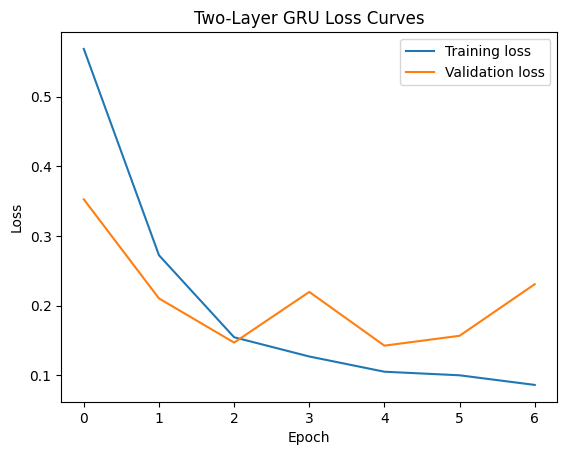

Two-Layer GRU {'accuracy': 0.9552631578947368, 'precision': 0.7410714285714286, 'recall': 0.9431818181818182, 'f1': 0.83}
              precision    recall  f1-score   support

         ham       0.99      0.96      0.97       672
        spam       0.74      0.94      0.83        88

    accuracy                           0.96       760
   macro avg       0.87      0.95      0.90       760
weighted avg       0.96      0.96      0.96       760



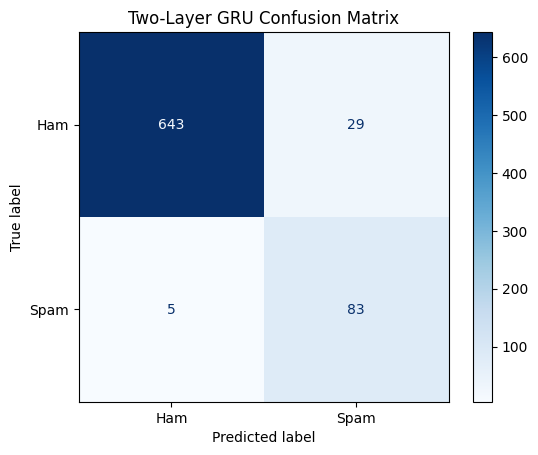

In [26]:
gru_2_history = train_model(
    gru_2_model, gru_2_optimizer, gru_2_criterion, "Two-Layer GRU"
)
gru_2_results = evaluate_model(gru_2_model, "Two-Layer GRU")


## 3. GloVe with LSTM

The regular LSTM class is used for the single-layer and two-layer experiments. A separate class below defines the bidirectional LSTM.

In [27]:
class GloveLSTM(nn.Module):
    def __init__(
        self, pretrained_weights, embedding_dim, hidden_size,
        num_layers, dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            pretrained_weights, freeze=True, padding_idx=PAD_ID
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        hidden = hidden[-1]

        return self.output(hidden).squeeze(1)

### Create the single-layer LSTM, loss function, and optimizer

In [28]:
torch.manual_seed(SEED)
train_loader.generator.manual_seed(SEED)

lstm_model = GloveLSTM(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32,
    num_layers=1,
    dropout=0.0
).to(device)

lstm_criterion = nn.BCEWithLogitsLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print(lstm_model)

GloveLSTM(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (lstm): LSTM(100, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


### Train the single-layer LSTM

Single-Layer LSTM | Epoch 1/20 | Train Loss: 0.5889 | Validation Loss: 0.3749
Single-Layer LSTM | Epoch 2/20 | Train Loss: 0.3587 | Validation Loss: 0.2466
Single-Layer LSTM | Epoch 3/20 | Train Loss: 0.2048 | Validation Loss: 0.1710
Single-Layer LSTM | Epoch 4/20 | Train Loss: 0.1496 | Validation Loss: 0.1717
Single-Layer LSTM | Epoch 5/20 | Train Loss: 0.1194 | Validation Loss: 0.1588
Single-Layer LSTM | Epoch 6/20 | Train Loss: 0.1027 | Validation Loss: 0.1700
Single-Layer LSTM | Epoch 7/20 | Train Loss: 0.0920 | Validation Loss: 0.2159
Early stopping at epoch 7
Restored weights from epoch 5


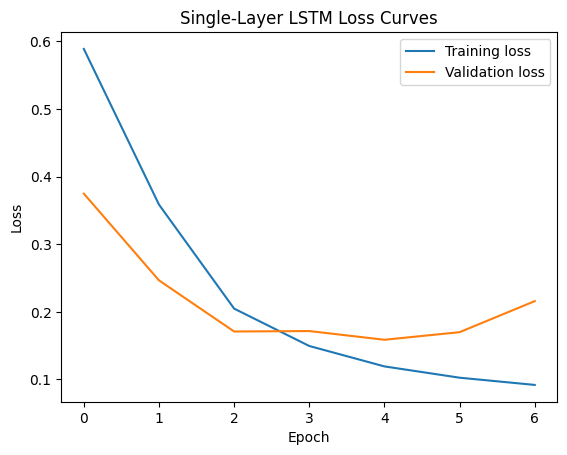

In [29]:
lstm_history = train_model(
    lstm_model, lstm_optimizer, lstm_criterion, "Single-Layer LSTM"
)


### Evaluate the single-layer LSTM

Single-Layer LSTM {'accuracy': 0.9407894736842105, 'precision': 0.6747967479674797, 'recall': 0.9431818181818182, 'f1': 0.7867298578199052}
              precision    recall  f1-score   support

         ham       0.99      0.94      0.97       672
        spam       0.67      0.94      0.79        88

    accuracy                           0.94       760
   macro avg       0.83      0.94      0.88       760
weighted avg       0.96      0.94      0.94       760



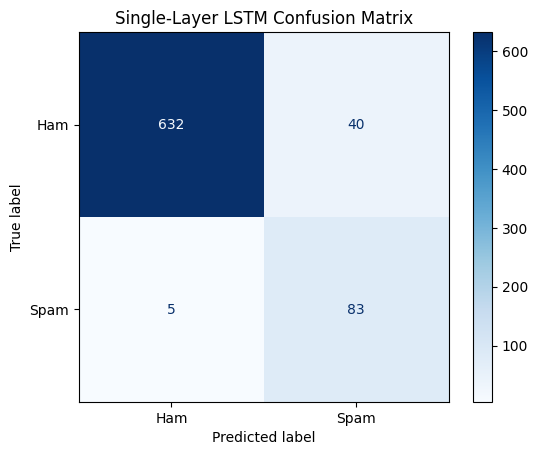

In [30]:
lstm_results = evaluate_model(lstm_model, "Single-Layer LSTM")


### Two-Layer LSTM

In [31]:
torch.manual_seed(SEED)

lstm_2_model = GloveLSTM(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32,
    num_layers=2,
    dropout=0.3
).to(device)

lstm_2_criterion = nn.BCEWithLogitsLoss()
lstm_2_optimizer = torch.optim.Adam(lstm_2_model.parameters(), lr=0.001)

print(lstm_2_model)

GloveLSTM(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (lstm): LSTM(100, 32, num_layers=2, batch_first=True, dropout=0.3)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


Two-Layer LSTM | Epoch 1/20 | Train Loss: 0.6350 | Validation Loss: 0.3976
Two-Layer LSTM | Epoch 2/20 | Train Loss: 0.3408 | Validation Loss: 0.3298
Two-Layer LSTM | Epoch 3/20 | Train Loss: 0.1884 | Validation Loss: 0.1475
Two-Layer LSTM | Epoch 4/20 | Train Loss: 0.1396 | Validation Loss: 0.1578
Two-Layer LSTM | Epoch 5/20 | Train Loss: 0.1161 | Validation Loss: 0.1477
Early stopping at epoch 5
Restored weights from epoch 3


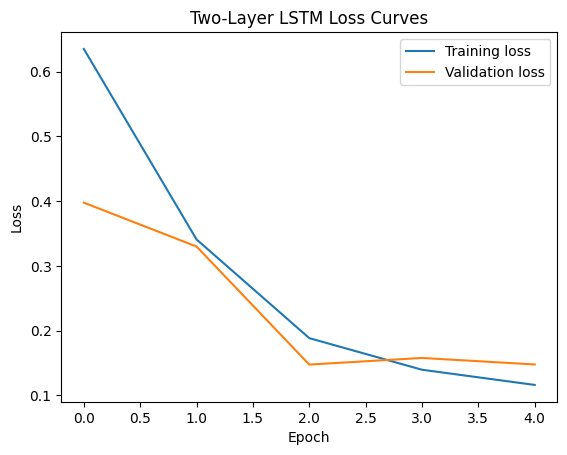

Two-Layer LSTM {'accuracy': 0.9513157894736842, 'precision': 0.7256637168141593, 'recall': 0.9318181818181818, 'f1': 0.8159203980099502}
              precision    recall  f1-score   support

         ham       0.99      0.95      0.97       672
        spam       0.73      0.93      0.82        88

    accuracy                           0.95       760
   macro avg       0.86      0.94      0.89       760
weighted avg       0.96      0.95      0.95       760



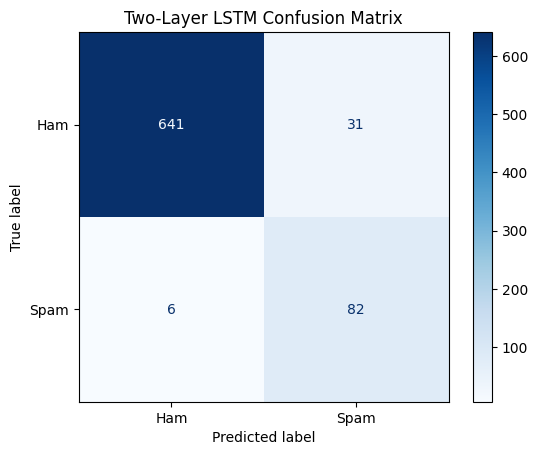

In [32]:
lstm_2_history = train_model(
    lstm_2_model, lstm_2_optimizer, lstm_2_criterion, "Two-Layer LSTM"
)
lstm_2_results = evaluate_model(lstm_2_model, "Two-Layer LSTM")


### Bidirectional LSTM

In [33]:
class GloveBiLSTM(nn.Module):
    def __init__(self, pretrained_weights, embedding_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            pretrained_weights, freeze=True, padding_idx=PAD_ID
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )
        self.output = nn.Linear(hidden_size * 2, 1)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.output(hidden).squeeze(1)


torch.manual_seed(SEED)

bilstm_model = GloveBiLSTM(
    pretrained_weights=embedding_tensor,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=32
).to(device)

bilstm_criterion = nn.BCEWithLogitsLoss()
bilstm_optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=0.001)

print(bilstm_model)

GloveBiLSTM(
  (embedding): Embedding(2886, 100, padding_idx=0)
  (lstm): LSTM(100, 32, batch_first=True, bidirectional=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
)


Bidirectional LSTM | Epoch 1/20 | Train Loss: 0.5805 | Validation Loss: 0.3657
Bidirectional LSTM | Epoch 2/20 | Train Loss: 0.3183 | Validation Loss: 0.2148
Bidirectional LSTM | Epoch 3/20 | Train Loss: 0.1605 | Validation Loss: 0.1501
Bidirectional LSTM | Epoch 4/20 | Train Loss: 0.1203 | Validation Loss: 0.1441
Bidirectional LSTM | Epoch 5/20 | Train Loss: 0.0943 | Validation Loss: 0.1507
Bidirectional LSTM | Epoch 6/20 | Train Loss: 0.0843 | Validation Loss: 0.1672
Early stopping at epoch 6
Restored weights from epoch 4


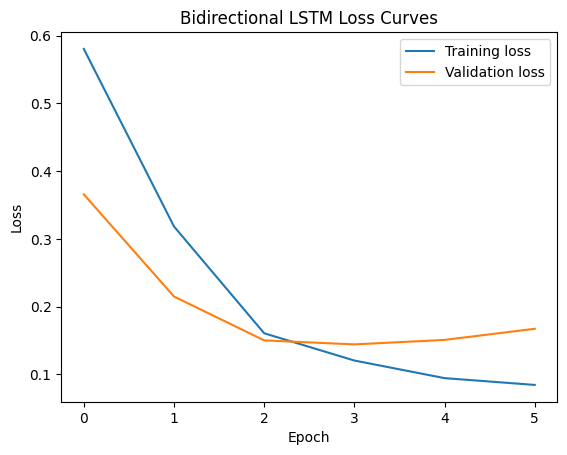

Bidirectional LSTM {'accuracy': 0.9368421052631579, 'precision': 0.6639344262295082, 'recall': 0.9204545454545454, 'f1': 0.7714285714285715}
              precision    recall  f1-score   support

         ham       0.99      0.94      0.96       672
        spam       0.66      0.92      0.77        88

    accuracy                           0.94       760
   macro avg       0.83      0.93      0.87       760
weighted avg       0.95      0.94      0.94       760



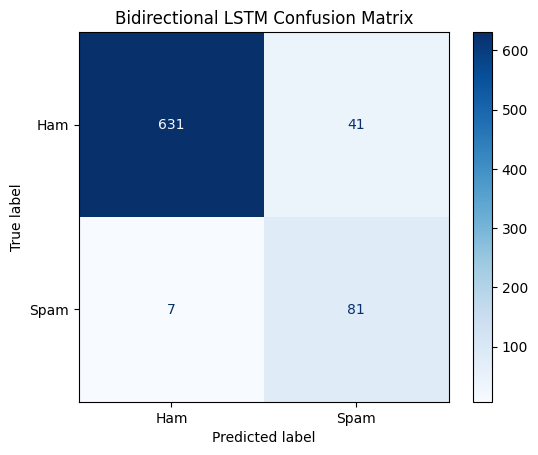

In [34]:
bilstm_history = train_model(
    bilstm_model, bilstm_optimizer, bilstm_criterion, "Bidirectional LSTM"
)
bilstm_results = evaluate_model(bilstm_model, "Bidirectional LSTM")


## 4. Hyperparameter Experiments

The trials below use **validation F1**, never the test set, to compare hidden size, learning rate, batch size, number of layers, and dropout. Each short trial uses five epochs so tuning remains manageable. The final test set should only be used after choosing a configuration.


In [35]:
def validation_f1(model):
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for token_ids, labels, lengths in validation_loader:
            logits = model(token_ids.to(device), lengths)
            predictions = (torch.sigmoid(logits) >= 0.5).int().cpu()
            true_labels.extend(labels.int().numpy())
            predicted_labels.extend(predictions.numpy())

    return f1_score(true_labels, predicted_labels)


def run_trial(model, learning_rate, batch_size, epochs=5):
    trial_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor, train_lengths_tensor),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for _ in range(epochs):
        model.train()
        for token_ids, labels, lengths in trial_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(token_ids, lengths), labels)
            loss.backward()
            optimizer.step()

        validation_loss = calculate_loss(
            model, validation_loader, criterion
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == 2:
            break

    model.load_state_dict(best_state)
    return validation_f1(model)


In [36]:
trials = [
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 32},
    {"hidden_size": 16, "learning_rate": 0.001, "batch_size": 32},
    {"hidden_size": 64, "learning_rate": 0.001, "batch_size": 32},
    {"hidden_size": 32, "learning_rate": 0.0005, "batch_size": 32},
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 16},
]

tuning_results = []

for model_name in ["RNN", "Bidirectional LSTM"]:
    for config in trials:
        torch.manual_seed(SEED)

        if model_name == "RNN":
            model = GloveRNN(
                embedding_tensor, EMBEDDING_DIM, config["hidden_size"]
            ).to(device)
        else:
            model = GloveBiLSTM(
                embedding_tensor, EMBEDDING_DIM, config["hidden_size"]
            ).to(device)

        score = run_trial(
            model, config["learning_rate"], config["batch_size"]
        )
        tuning_results.append({
            "Model": model_name,
            "Layers": 1,
            "Dropout": 0.0,
            **config,
            "Validation F1": score
        })

recurrent_trials = [
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 32,
     "num_layers": 1, "dropout": 0.0},
    {"hidden_size": 16, "learning_rate": 0.001, "batch_size": 32,
     "num_layers": 1, "dropout": 0.0},
    {"hidden_size": 64, "learning_rate": 0.001, "batch_size": 32,
     "num_layers": 1, "dropout": 0.0},
    {"hidden_size": 32, "learning_rate": 0.0005, "batch_size": 32,
     "num_layers": 1, "dropout": 0.0},
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 16,
     "num_layers": 1, "dropout": 0.0},
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 32,
     "num_layers": 2, "dropout": 0.0},
    {"hidden_size": 32, "learning_rate": 0.001, "batch_size": 32,
     "num_layers": 2, "dropout": 0.3},
]

for model_name, model_class in [("GRU", GloveGRU), ("LSTM", GloveLSTM)]:
    for config in recurrent_trials:
        torch.manual_seed(SEED)
        model = model_class(
            pretrained_weights=embedding_tensor,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"]
        ).to(device)

        score = run_trial(
            model, config["learning_rate"], config["batch_size"]
        )
        tuning_results.append({
            "Model": model_name,
            "Layers": config["num_layers"],
            "Dropout": config["dropout"],
            "hidden_size": config["hidden_size"],
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "Validation F1": score
        })

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values(["Model", "Validation F1"], ascending=[True, False])


,Model,Layers,Dropout,hidden_size,learning_rate,batch_size,Validation F1
7,Bidirectional LSTM,1,0.0,64,0.0010,32,0.833333
9,Bidirectional LSTM,1,0.0,32,0.0010,16,0.802030
5,Bidirectional LSTM,1,0.0,32,0.0010,32,0.791878
8,Bidirectional LSTM,1,0.0,32,0.0005,32,0.782178
6,Bidirectional LSTM,1,0.0,16,0.0010,32,0.775120
10,GRU,1,0.0,32,0.0010,32,0.837989
14,GRU,1,0.0,32,0.0010,16,0.821622
16,GRU,2,0.3,32,0.0010,32,0.814815
12,GRU,1,0.0,64,0.0010,32,0.793478
15,GRU,2,0.0,32,0.0010,32,0.793478


### Best validation configuration for each architecture

Compare these rows to document how changing capacity, learning rate, batch size, layers, and dropout affected validation F1.


In [37]:
best_configurations = tuning_df.loc[
    tuning_df.groupby("Model")["Validation F1"].idxmax()
].sort_values("Model").reset_index(drop=True)

best_configurations


,Model,Layers,Dropout,hidden_size,learning_rate,batch_size,Validation F1
0,Bidirectional LSTM,1,0.0,64,0.001,32,0.833333
1,GRU,1,0.0,32,0.001,32,0.837989
2,LSTM,1,0.0,32,0.001,16,0.858757
3,RNN,1,0.0,64,0.001,32,0.795699


## 5. Initial Architecture Comparison

This table compares the six original GloVe configurations before final retraining with the selected hyperparameters.


In [38]:
comparison_df = pd.DataFrame([
    {"Model": "RNN Baseline", "Layers": 1, "Bidirectional": False,
     **{key.title(): value for key, value in rnn_results.items()}},
    {"Model": "Single-Layer GRU", "Layers": 1, "Bidirectional": False,
     **{key.title(): value for key, value in gru_results.items()}},
    {"Model": "Two-Layer GRU", "Layers": 2, "Bidirectional": False,
     **{key.title(): value for key, value in gru_2_results.items()}},
    {"Model": "Single-Layer LSTM", "Layers": 1, "Bidirectional": False,
     **{key.title(): value for key, value in lstm_results.items()}},
    {"Model": "Two-Layer LSTM", "Layers": 2, "Bidirectional": False,
     **{key.title(): value for key, value in lstm_2_results.items()}},
    {"Model": "Bidirectional LSTM", "Layers": 1, "Bidirectional": True,
     **{key.title(): value for key, value in bilstm_results.items()}},
])

comparison_df.sort_values("F1", ascending=False).reset_index(drop=True)


,Model,Layers,Bidirectional,Accuracy,Precision,Recall,F1
0,Two-Layer GRU,2,False,0.955263,0.741071,0.943182,0.830000
1,Single-Layer GRU,1,False,0.955263,0.745455,0.931818,0.828283
2,Two-Layer LSTM,2,False,0.951316,0.725664,0.931818,0.815920
3,Single-Layer LSTM,1,False,0.940789,0.674797,0.943182,0.786730
4,Bidirectional LSTM,1,True,0.936842,0.663934,0.920455,0.771429
5,RNN Baseline,1,False,0.931579,0.663636,0.829545,0.737374


## 6. Final Evaluation After Tuning

For each architecture, create a fresh model using the best validation configuration, retrain it with early stopping, and evaluate it once on the held-out test set.


In [40]:
def build_tuned_model(config):
    model_name = config["Model"]
    hidden_size = int(config["hidden_size"])

    if model_name == "RNN":
        return GloveRNN(
            embedding_tensor, EMBEDDING_DIM, hidden_size
        ).to(device)

    if model_name == "GRU":
        return GloveGRU(
            pretrained_weights=embedding_tensor,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=hidden_size,
            num_layers=int(config["Layers"]),
            dropout=float(config["Dropout"])
        ).to(device)

    if model_name == "LSTM":
        return GloveLSTM(
            pretrained_weights=embedding_tensor,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=hidden_size,
            num_layers=int(config["Layers"]),
            dropout=float(config["Dropout"])
        ).to(device)

    return GloveBiLSTM(
        embedding_tensor, EMBEDDING_DIM, hidden_size
    ).to(device)


### Retrain the selected configurations and test them


Tuned Bidirectional LSTM | Epoch 1/20 | Train Loss: 0.5408 | Validation Loss: 0.2700
Tuned Bidirectional LSTM | Epoch 2/20 | Train Loss: 0.2030 | Validation Loss: 0.2249
Tuned Bidirectional LSTM | Epoch 3/20 | Train Loss: 0.1580 | Validation Loss: 0.1285
Tuned Bidirectional LSTM | Epoch 4/20 | Train Loss: 0.1157 | Validation Loss: 0.1767
Tuned Bidirectional LSTM | Epoch 5/20 | Train Loss: 0.0873 | Validation Loss: 0.1747
Early stopping at epoch 5
Restored weights from epoch 3


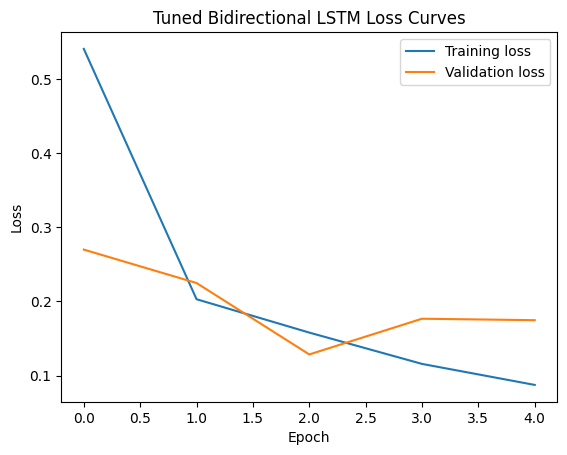

Tuned Bidirectional LSTM {'accuracy': 0.9565789473684211, 'precision': 0.7669902912621359, 'recall': 0.8977272727272727, 'f1': 0.8272251308900523}
              precision    recall  f1-score   support

         ham       0.99      0.96      0.98       672
        spam       0.77      0.90      0.83        88

    accuracy                           0.96       760
   macro avg       0.88      0.93      0.90       760
weighted avg       0.96      0.96      0.96       760



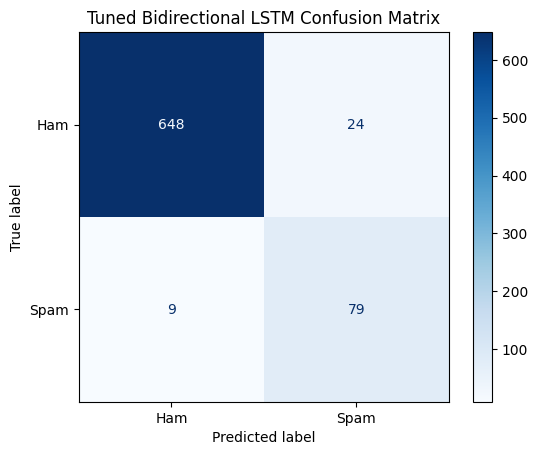

Tuned GRU | Epoch 1/20 | Train Loss: 0.5983 | Validation Loss: 0.3924
Tuned GRU | Epoch 2/20 | Train Loss: 0.4445 | Validation Loss: 0.2998
Tuned GRU | Epoch 3/20 | Train Loss: 0.2460 | Validation Loss: 0.2092
Tuned GRU | Epoch 4/20 | Train Loss: 0.1680 | Validation Loss: 0.1665
Tuned GRU | Epoch 5/20 | Train Loss: 0.1323 | Validation Loss: 0.1377
Tuned GRU | Epoch 6/20 | Train Loss: 0.1128 | Validation Loss: 0.1508
Tuned GRU | Epoch 7/20 | Train Loss: 0.0940 | Validation Loss: 0.1685
Early stopping at epoch 7
Restored weights from epoch 5


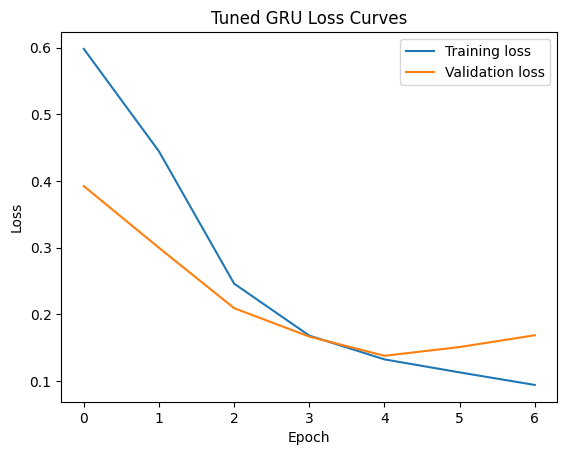

Tuned GRU {'accuracy': 0.9552631578947368, 'precision': 0.7454545454545455, 'recall': 0.9318181818181818, 'f1': 0.8282828282828283}
              precision    recall  f1-score   support

         ham       0.99      0.96      0.97       672
        spam       0.75      0.93      0.83        88

    accuracy                           0.96       760
   macro avg       0.87      0.95      0.90       760
weighted avg       0.96      0.96      0.96       760



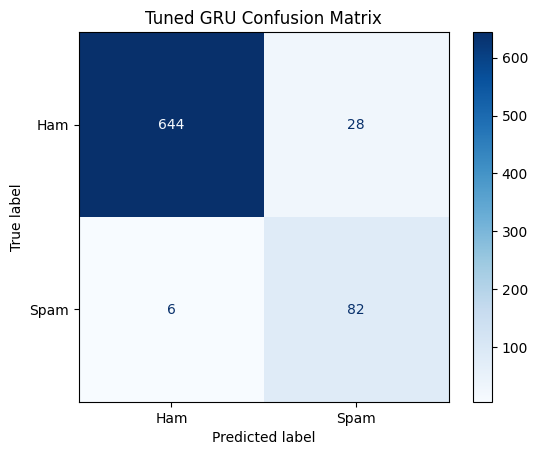

Tuned LSTM | Epoch 1/20 | Train Loss: 0.5019 | Validation Loss: 0.2636
Tuned LSTM | Epoch 2/20 | Train Loss: 0.2017 | Validation Loss: 0.1547
Tuned LSTM | Epoch 3/20 | Train Loss: 0.1424 | Validation Loss: 0.1386
Tuned LSTM | Epoch 4/20 | Train Loss: 0.1069 | Validation Loss: 0.1313
Tuned LSTM | Epoch 5/20 | Train Loss: 0.0842 | Validation Loss: 0.1231
Tuned LSTM | Epoch 6/20 | Train Loss: 0.0779 | Validation Loss: 0.1684
Tuned LSTM | Epoch 7/20 | Train Loss: 0.0646 | Validation Loss: 0.1552
Early stopping at epoch 7
Restored weights from epoch 5


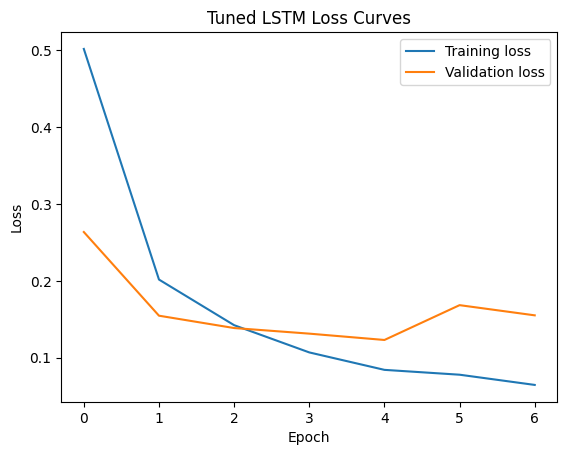

Tuned LSTM {'accuracy': 0.9473684210526315, 'precision': 0.7142857142857143, 'recall': 0.9090909090909091, 'f1': 0.8}
              precision    recall  f1-score   support

         ham       0.99      0.95      0.97       672
        spam       0.71      0.91      0.80        88

    accuracy                           0.95       760
   macro avg       0.85      0.93      0.88       760
weighted avg       0.96      0.95      0.95       760



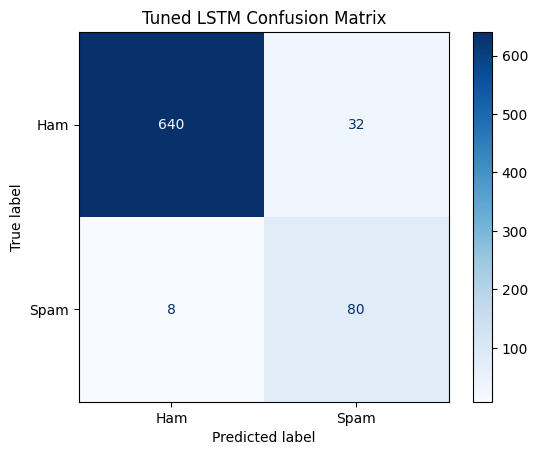

Tuned RNN | Epoch 1/20 | Train Loss: 0.5167 | Validation Loss: 0.2395
Tuned RNN | Epoch 2/20 | Train Loss: 0.2202 | Validation Loss: 0.1815
Tuned RNN | Epoch 3/20 | Train Loss: 0.1718 | Validation Loss: 0.1665
Tuned RNN | Epoch 4/20 | Train Loss: 0.1330 | Validation Loss: 0.1460
Tuned RNN | Epoch 5/20 | Train Loss: 0.1292 | Validation Loss: 0.1428
Tuned RNN | Epoch 6/20 | Train Loss: 0.1071 | Validation Loss: 0.1900
Tuned RNN | Epoch 7/20 | Train Loss: 0.1406 | Validation Loss: 0.2052
Early stopping at epoch 7
Restored weights from epoch 5


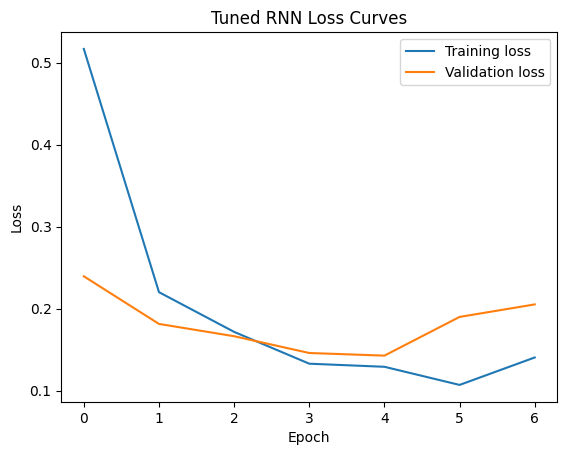

Tuned RNN {'accuracy': 0.9368421052631579, 'precision': 0.6612903225806451, 'recall': 0.9318181818181818, 'f1': 0.7735849056603774}
              precision    recall  f1-score   support

         ham       0.99      0.94      0.96       672
        spam       0.66      0.93      0.77        88

    accuracy                           0.94       760
   macro avg       0.83      0.93      0.87       760
weighted avg       0.95      0.94      0.94       760



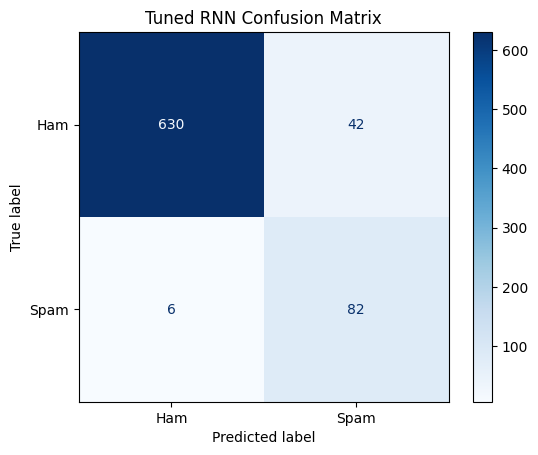

In [43]:
final_tuned_results = []
final_tuned_models = {}

for _, config in best_configurations.iterrows():
    model_name = config["Model"]
    batch_size = int(config["batch_size"])
    learning_rate = float(config["learning_rate"])

    tuned_train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor, train_lengths_tensor),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    torch.manual_seed(SEED)
    model = build_tuned_model(config)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = train_model(
        model, optimizer, criterion, f"Tuned {model_name}",
        training_loader=tuned_train_loader
    )
    test_results = evaluate_model(model, f"Tuned {model_name}")

    final_tuned_models[model_name] = model
    final_tuned_results.append({
        "Model": model_name,
        "Hidden Size": int(config["hidden_size"]),
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Layers": int(config["Layers"]),
        "Dropout": float(config["Dropout"]),
        "Best Epoch": history["best_epoch"],
        **{key.title(): value for key, value in test_results.items()}
    })


### Final tuned-model comparison


In [44]:
final_tuned_comparison = pd.DataFrame(final_tuned_results)
final_tuned_comparison.sort_values(
    "F1", ascending=False
).reset_index(drop=True)


,Model,Hidden Size,Learning Rate,Batch Size,Layers,Dropout,Best Epoch,Accuracy,Precision,Recall,F1
0,GRU,32,0.001,32,1,0.0,5,0.955263,0.745455,0.931818,0.828283
1,Bidirectional LSTM,64,0.001,32,1,0.0,3,0.956579,0.766990,0.897727,0.827225
2,LSTM,32,0.001,16,1,0.0,5,0.947368,0.714286,0.909091,0.800000
3,RNN,64,0.001,32,1,0.0,5,0.936842,0.661290,0.931818,0.773585
